In [ ]:
%load_ext cudf.pandas

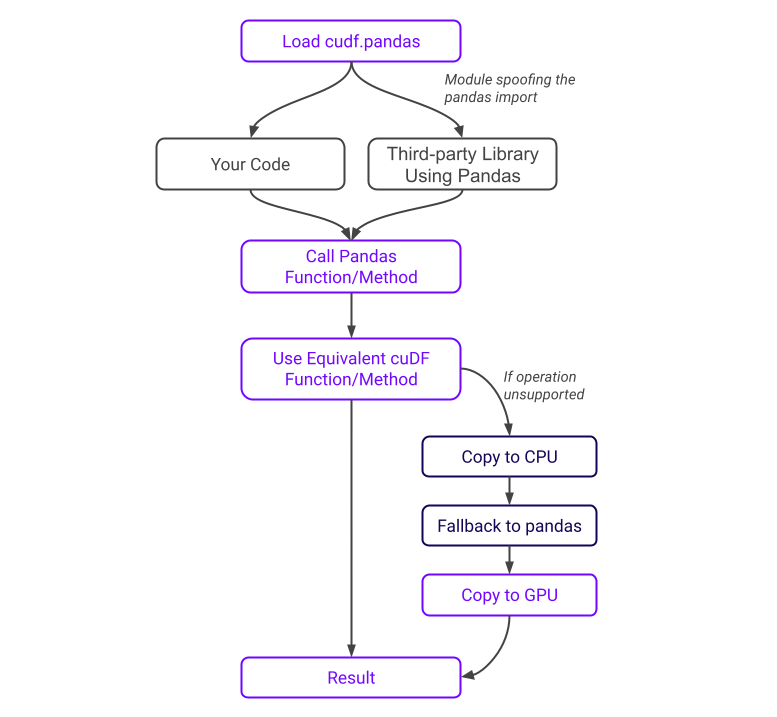

In [2]:
import os
os.environ["TABPFN_MODEL_CACHE_DIR"] = "/home/azureuser/cloudfiles/data/tabpfn-3"

In [3]:
import pathlib
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

COMP_DIR = pathlib.Path("/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/data")

if not COMP_DIR.exists():
    COMP_DIR = ''

# COMPETITION DATA
train = pd.read_csv(COMP_DIR / "train.csv", index_col="id")
test = pd.read_csv(COMP_DIR / "test.csv", index_col="id")
sample_submission = pd.read_csv(COMP_DIR / "sample_submission.csv")

train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

print(train.shape, test.shape)

(577347, 11) (247435, 10)


In [4]:
train.head(5)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [5]:
ohe_df = pd.get_dummies(train[["spectral_type", "galaxy_population"]], drop_first=True, dtype="int")
ohe_df.columns = ohe_df.columns.str.lower()

train = pd.concat([train, ohe_df], axis=1)
train = train.drop(columns=["spectral_type", "galaxy_population"])

In [6]:
ohe_df_test = pd.get_dummies(test[["spectral_type", "galaxy_population"]], drop_first=True, dtype="int")
ohe_df_test.columns = ohe_df_test.columns.str.lower()

test = pd.concat([test, ohe_df_test], axis=1)
test = test.drop(columns=["spectral_type", "galaxy_population"])

In [7]:
TARGET = "class"
NUM_COLS = [c for c in train.select_dtypes(include=["number"]).columns]
CAT_COLS = [c for c in train.columns if c not in NUM_COLS + [TARGET]]

In [8]:
TARGET_MAPPING = {
    "GALAXY": 0,
    "QSO": 1,
    "STAR": 2
}

train[TARGET] = train[TARGET].map(TARGET_MAPPING)

In [9]:
import torch

device = "gpu" if torch.cuda.is_available() else "cpu"


XGB_PARAMS = {
    "objective": "multi:softprob",
    "num_class": 3,
    "tree_method": "hist",
    "device": device,
    "n_estimators": 10000,
    "learning_rate": 0.01,
    "max_depth": 6,
    "min_child_weight": 10,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "random_state": 42,
    "enable_categorical": True
}

In [13]:
import os
import numpy as np
import tabpfn_client
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from tabpfn import TabPFNClassifier
import logging

logging.getLogger("tabpfn").setLevel(logging.DEBUG)

MODEL_IN_USE = 'TABPFN'

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

X = train[NUM_COLS + CAT_COLS]
y = train[TARGET]

X_test = test[NUM_COLS + CAT_COLS]

oof_probs = np.zeros((X.shape[0], 3))
tst_probs = np.zeros((X_test.shape[0], 3))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    if MODEL_IN_USE == 'XGB':

        print('Using XGB Model')

        model = XGBClassifier(
            **XGB_PARAMS
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            sample_weight=train_weights,
            verbose=0
        )

    if MODEL_IN_USE == 'TABPFN':

        print('Using TABPFN Model')

        model = TabPFNClassifier(
            device=["cuda:0"],
            n_estimators=2,
            eval_metric="balanced_accuracy",
            tuning_config={
                "tune_decision_thresholds": True,
            },
            model_path="/home/azureuser/cloudfiles/data/tabpfn-3/tabpfn-v3-classifier-v3_20260417_multiclass.ckpt",
        )
        
        model.fit(X_train, y_train)

    oof_probs[val_idx] = model.predict_proba(X_val)
    tst_probs += model.predict_proba(X_test)

    oof_score = balanced_accuracy_score(y_val, np.argmax(oof_probs[val_idx], axis=1))
    print(f'Fold {fold+1} Balanced Accuracy: {oof_score:.5f}')

tst_probs /= 5

oof_score_full = balanced_accuracy_score(y, np.argmax(oof_probs, axis=1))

print(f"Full OOF balanced_accuracy: {oof_score_full:.5f}")

Using TABPFN Model
Fold 1 Balanced Accuracy: 0.96045
Using TABPFN Model
Fold 2 Balanced Accuracy: 0.96091
Using TABPFN Model
Fold 3 Balanced Accuracy: 0.96045
Using TABPFN Model
Fold 4 Balanced Accuracy: 0.95988
Using TABPFN Model
Fold 5 Balanced Accuracy: 0.96069
Full OOF balanced_accuracy: 0.96048


In [14]:
oof_df = pd.DataFrame(
    oof_probs, columns=['p1', 'p2', 'p3']
)

oof_df['class'] = y.values

oof_df.to_parquet('/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/submissions/oof_tabpfn.parquet', index=False)

In [15]:
tst_df = pd.DataFrame(
    tst_probs, columns=['p1', 'p2', 'p3']
)

oof_df.to_parquet('/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/submissions/oof_test_tabpfn.parquet', index=False)

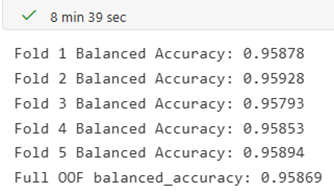

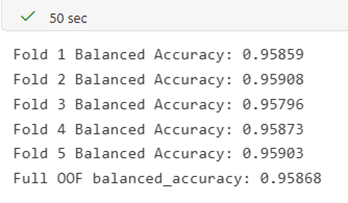

In [16]:
from scipy.optimize import minimize, differential_evolution

init_weights = np.ones(3)
bounds = [(0.01, 10), (0.01, 10), (0.01, 10)]

def threshold_objective(weights, oof_probs, y_true):

    scaled_probs = oof_probs * weights

    preds = np.argmax(scaled_probs, axis=1)

    score = balanced_accuracy_score(y_true, preds)

    return -score

threshold_result = differential_evolution(
    threshold_objective,
    bounds=bounds,
    args=(oof_probs, y.to_numpy()),
    seed=42,
    maxiter=1000,
    popsize=20,
    polish=False
)


In [17]:
threshold_result

             message: Optimization terminated successfully.
             success: True
                 fun: -0.9609384170135948
                   x: [ 4.724e+00  6.652e+00  4.917e+00]
                 nit: 1
                nfev: 120
          population: [[ 4.724e+00  6.652e+00  4.917e+00]
                       [ 8.004e+00  8.412e+00  9.172e+00]
                       ...
                       [ 8.238e+00  9.696e+00  5.599e+00]
                       [ 4.609e+00  2.002e+00  6.593e+00]]
 population_energies: [-9.609e-01 -9.605e-01 ... -9.603e-01 -9.580e-01]

In [18]:
best_weights = threshold_result.x

In [19]:
-threshold_result.fun

np.float64(0.9609384170135948)

In [20]:
TARGET_MAPPING_INV = {
    0: "GALAXY",
    1: "QSO",
    2: "STAR"
}

In [21]:
SUBMISSION_PATH = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/submissions"
SUBMISSION_PATH = pathlib.Path(SUBMISSION_PATH)

sample_submission['class'] = np.argmax(tst_probs * best_weights, axis=1)
sample_submission['class'] = sample_submission['class'].map(TARGET_MAPPING_INV)
sample_submission.to_csv(SUBMISSION_PATH / 'submission_tabpfn.csv', index=False)

In [22]:
sample_submission

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
...,...,...
247430,824777,QSO
247431,824778,QSO
247432,824779,GALAXY
247433,824780,QSO


In [79]:
import optuna

optuna.logging.set_verbosity(optuna.logging.INFO)

def xgb_objective(trial):

    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "tree_method": "hist",
        "device": device,
        "random_state": 42,
        "enable_categorical": True,
        "n_estimators": 10000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
    }

    skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

    X = train[NUM_COLS + CAT_COLS]
    y = train[TARGET]

    oof_probs = np.zeros((X.shape[0], 3))
    oof_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

        model = XGBClassifier(
            **params
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            sample_weight=train_weights,
            verbose=0
        )

        oof_probs[val_idx] = model.predict_proba(X_val)
        oof_score = balanced_accuracy_score(y_val, np.argmax(oof_probs[val_idx], axis=1))
        oof_scores.append(oof_score)

        trial.report(np.mean(oof_scores), step=1)
        if trial.should_prune():
            raise optuna.TrialPruned()

    oof_score_full = balanced_accuracy_score(y, np.argmax(oof_probs, axis=1))

    return oof_score_full

In [80]:
tpe_sampler = optuna.samplers.TPESampler()

study = optuna.create_study(
    direction="maximize",
    sampler=tpe_sampler,
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1
    )
)

study.optimize(xgb_objective, n_trials=100)

[I 2026-06-05 12:38:22,355] A new study created in memory with name: no-name-61178d68-6950-4d5f-9f40-1056d9902ef3
[I 2026-06-05 12:44:57,685] Trial 0 finished with value: 0.9632528144682481 and parameters: {'learning_rate': 0.05810664356559112, 'max_depth': 5, 'min_child_weight': 19, 'subsample': 0.9380491732624326, 'colsample_bytree': 0.957464774762677, 'reg_alpha': 2.9225157496600326e-07, 'reg_lambda': 0.03895323348122032}. Best is trial 0 with value: 0.9632528144682481.
[I 2026-06-05 12:55:18,114] Trial 1 finished with value: 0.9614498763721574 and parameters: {'learning_rate': 0.0011028237841782687, 'max_depth': 7, 'min_child_weight': 15, 'subsample': 0.6575812552182029, 'colsample_bytree': 0.7561919415691805, 'reg_alpha': 0.00028726388356039667, 'reg_lambda': 0.0003319577984461939}. Best is trial 0 with value: 0.9632528144682481.
[I 2026-06-05 13:06:52,897] Trial 2 finished with value: 0.9592846622504901 and parameters: {'learning_rate': 0.03324654004289053, 'max_depth': 8, 'min_c

KeyboardInterrupt: 